In [ ]:
%load_ext autoreload
%autoreload 2

import numpy as np
import xarray as xr
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.patheffects as pe
from matplotlib.gridspec import GridSpec
from matplotlib.colors import BoundaryNorm
from matplotlib.patches import Rectangle
from windspharm.xarray import VectorWind
from pathlib import Path

import sys
module_path = "../bin"
sys.path.insert(0,module_path)

import um_utils_plotting as umplt
import um_utils as um
from geometry_fix import apply_geometry_collection_fix

apply_geometry_collection_fix()

um.WarningSuppress()

MEANS_DIR = Path("../Data/Models/Monthly_Means")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Fig. S4 - MAM Drying Attribution

In [ ]:
#------------------------------------------------------------
# Import UKESM Simulated Climate
#------------------------------------------------------------

MH_means = um.importUMData(MEANS_DIR / "MH_monthly_means.nc")
PI_means = um.importUMData(MEANS_DIR / "PI_monthly_means.nc")

#------------------------------------------------------------
# Calculate Anomalies for plots
#------------------------------------------------------------

def vpot_divwind(u3d, v3d, months, level_pa=200):
    u = u3d.sel(p_levs=level_pa, method="nearest").isel(time=months).mean("time")
    v = v3d.sel(p_levs=level_pa, method="nearest").isel(time=months).mean("time")
    w = VectorWind(u, v)
    chi = w.velocitypotential() # Velocty Potential in m2 s-1
    u_chi, v_chi = w.irrotationalcomponent() # Divergent (irrotational) wind m s-1
    return chi, u_chi, v_chi

chi_M, uM, vM = vpot_divwind(MH_means["u_wind"], MH_means["v_wind"], months=[2, 3, 4])
chi_P, uP, vP = vpot_divwind(PI_means["u_wind"], PI_means["v_wind"], months=[2, 3, 4])

dchi = (chi_M - chi_P) * 1e-6
duchi, dvchi = uM - uP, vM - vP

pr_anom = (MH_means["pr"] - PI_means["pr"]).isel(time=[2, 3, 4]).mean(dim="time") * 12
p0_anom = (MH_means["surfpress"] - PI_means["surfpress"]).isel(time=[2, 3, 4]).mean(dim="time") / 100
ts_anom = (MH_means["ts"] - PI_means["ts"]).isel(time=[2, 3, 4]).mean(dim="time")

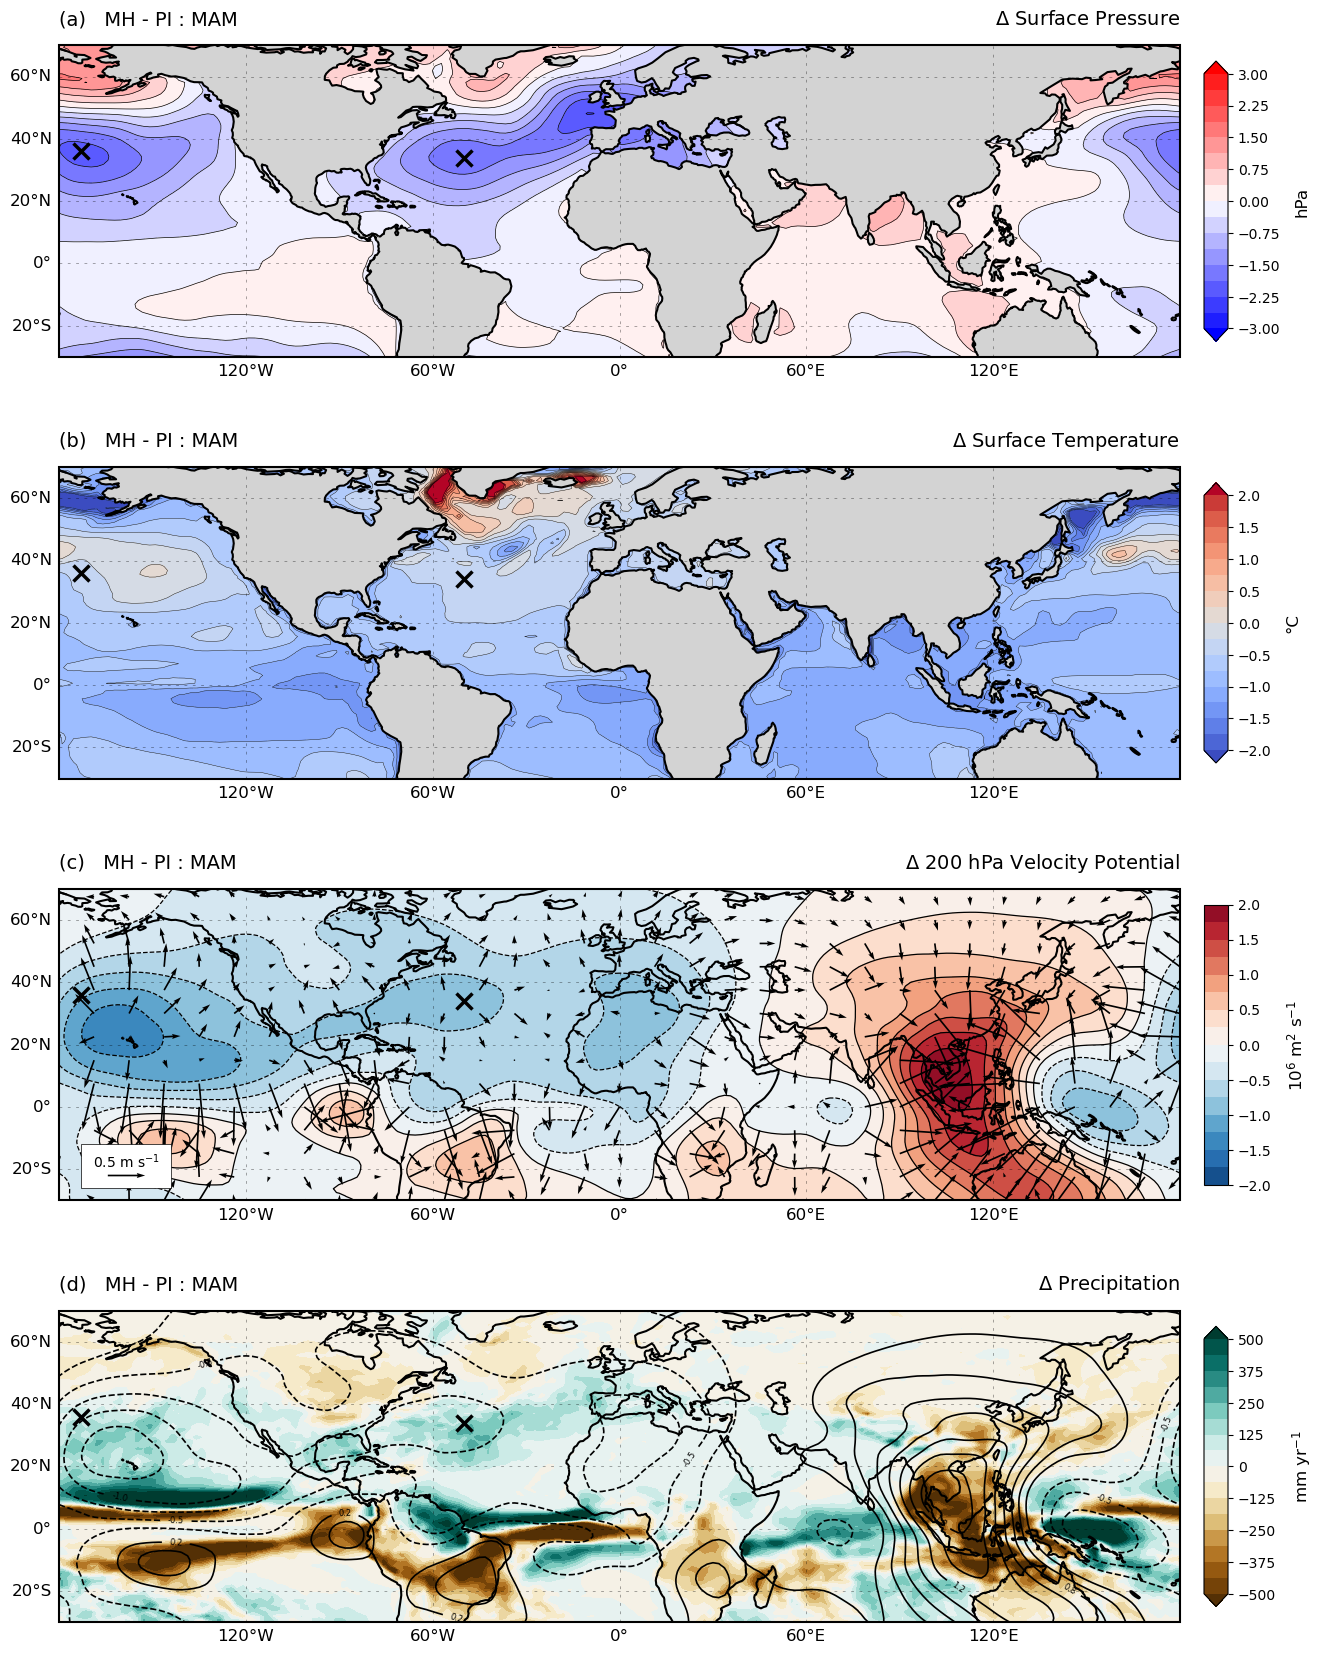

In [ ]:
#------------------------------------------------------------
# Figure Properties
#------------------------------------------------------------

fig = plt.figure(figsize=(12, 17))
gs = GridSpec(4, 1)
lims, proj = [-180, 180, -30, 70], ccrs.PlateCarree()

high_centres = {"E Pacific": (-173, 36), "NASH": (-50, 34)}

#------------------------------------------------------------
# Panel (a) - Surface Pressure Anomaly
#------------------------------------------------------------

ax_p = plt.subplot(gs[0], projection=proj)
umplt.plotBaseMap(ax_p, lims, coastlw=1.5, borders=False, land=True, spinelw=1.5)
umplt.plotGrid(ax_p, xlabeledlines=[-120, -60, 0, 60, 120], ylabeledlines=[-20, 0, 20, 40, 60],
               labelsize=12, lw=0.4, alph=0.6)

cmap = cm.bwr; v = 3; levels = np.linspace(-v, v, 17) 
norm = BoundaryNorm(levels, cmap.N, extend="both")

p0_c, lon_p0 = add_cyclic_point(p0_anom.values, coord=p0_anom.longitude)
cf_p = ax_p.contourf(lon_p0, p0_anom.latitude, p0_c, cmap=cmap, norm=norm, extend="both", levels=levels, transform=ccrs.PlateCarree(), zorder=0)
ax_p.contour(lon_p0, p0_anom.latitude, p0_c, colors="k", levels=levels, linewidths=0.5, linestyles="solid", transform=ccrs.PlateCarree(), zorder=0)

for name, (x, y) in high_centres.items():
    (cross, ) = ax_p.plot(x, y, "kx", ms=12, mew=2.5, transform=ccrs.PlateCarree(), zorder=3)

ax_p.set_title("(a)   MH - PI : MAM", loc="left", pad=15, fontsize=14)
ax_p.set_title(r"$\Delta$ Surface Pressure", loc="right", pad=15, fontsize=14)

#------------------------------------------------------------
# Panel (b) - Surface Temperature Anomaly
#------------------------------------------------------------

ax_t = plt.subplot(gs[1], projection=proj)
umplt.plotBaseMap(ax_t, lims, coastlw=1.5, borders=False, land=True, spinelw=1.5)
umplt.plotGrid(ax_t, xlabeledlines=[-120, -60, 0, 60, 120], ylabeledlines=[-20, 0, 20, 40, 60],
               labelsize=12, lw=0.4, alph=0.6)

cmap = cm.coolwarm; v = 2; levels = np.linspace(-v, v, 17) 
norm = BoundaryNorm(levels, cmap.N, extend="both")

ts_c, lon_ts = add_cyclic_point(ts_anom.values, coord=ts_anom.longitude)
cf_t = ax_t.contourf(lon_ts, ts_anom.latitude, ts_c, cmap=cmap, norm=norm, extend="both", levels=levels, transform=ccrs.PlateCarree(), zorder=0)
ax_t.contour(lon_ts, ts_anom.latitude, ts_c, colors="k", levels=levels, linewidths=0.3, linestyles="solid", transform=ccrs.PlateCarree(), zorder=0)

for name, (x, y) in high_centres.items():
    (cross, ) = ax_t.plot(x, y, "kx", ms=12, mew=2.5, transform=ccrs.PlateCarree(), zorder=3)

ax_t.set_title("(b)   MH - PI : MAM", loc="left", pad=15, fontsize=14)
ax_t.set_title(r"$\Delta$ Surface Temperature", loc="right", pad=15, fontsize=14)

#------------------------------------------------------------
# Panel (c) - Upper Level Velocity Potential + Wind Divergence
#------------------------------------------------------------

ax_chi = plt.subplot(gs[2], projection=proj)
umplt.plotBaseMap(ax_chi, lims, coastlw=1.5, borders=False, spinelw=1.5)
umplt.plotGrid(ax_chi, xlabeledlines=[-120, -60, 0, 60, 120], ylabeledlines=[-20, 0, 20, 40, 60],
               labelsize=12, lw=0.4, alph=0.6)

N = 6
LON, LAT = np.meshgrid(duchi.lon_p, duchi.lat_p)
cmap = cm.RdBu_r; v = 2; levels = np.linspace(-v, v, 17) 
norm = BoundaryNorm(levels, cmap.N, extend="both")

dchi_c, lon_dchi = add_cyclic_point(dchi.values, coord=dchi.lon_p)
cf_chi = ax_chi.contourf(lon_dchi, dchi.lat_p, dchi_c, cmap=cmap, norm=norm, levels=levels, transform=ccrs.PlateCarree(), zorder=0)
ax_chi.contour(lon_dchi, dchi.lat_p, dchi_c, colors="k", levels=levels, linewidths=0.9, transform=ccrs.PlateCarree(), zorder=0)
q = ax_chi.quiver(LON[::N, ::N], LAT[::N, ::N], duchi.values[::N, ::N], dvchi.values[::N, ::N], 
              transform=ccrs.PlateCarree(), scale=15, width=0.0015)

ax_chi.add_patch(Rectangle((0.02, 0.04), 0.08, 0.14, edgecolor=(0, 0, 0, 1), facecolor=(1, 1, 1, 1), linewidth=0.5, transform=ax_chi.transAxes, zorder=10))
ax_chi.quiverkey(q, 0.06, 0.08, 0.5, r"0.5 m s$^{-1}$", coordinates='axes', fontproperties={'size': 10}, color='k', labelsep=0.05, zorder=10)

for name, (x, y) in high_centres.items():
    (cross, ) = ax_chi.plot(x, y, "kx", ms=12, mew=2.5, transform=ccrs.PlateCarree(), zorder=3)

ax_chi.set_title("(c)   MH - PI : MAM", loc="left", pad=15, fontsize=14)
ax_chi.set_title(r"$\Delta$ 200 hPa Velocity Potential", loc="right", pad=15, fontsize=14)

#------------------------------------------------------------
# Panel (d) - Precipitation + Upper Level Velocity Potential Contours
#------------------------------------------------------------

cmap = cm.BrBG; v_pr = 500; levels = np.linspace(-v_pr, v_pr, 17) 
norm = BoundaryNorm(levels, cmap.N, extend="both")

ax_pr = plt.subplot(gs[3], projection=proj)
umplt.plotBaseMap(ax_pr, lims, coastlw=1.5, borders=False, spinelw=1.5)
umplt.plotGrid(ax_pr, xlabeledlines=[-120, -60, 0, 60, 120], ylabeledlines=[-20, 0, 20, 40, 60],
               labelsize=12, lw=0.4, alph=0.6)

pr_c, lon_pr = add_cyclic_point(pr_anom.values, coord=pr_anom.longitude)
cf_pr = ax_pr.contourf(lon_pr, pr_anom.latitude, pr_c, levels=levels, extend="both", cmap=cmap, norm=norm, transform=ccrs.PlateCarree(), zorder=0)

chi_c, lon_chi = add_cyclic_point(dchi.values, coord=dchi.lon_p)
v_chi = 2; clevs = np.linspace(-v_chi, v_chi, 17); clevs = clevs[clevs != 0]
cs = ax_pr.contour(lon_chi, dchi.lat_p, chi_c, levels=clevs, colors="k", linewidths=1.2,
                linestyles=np.where(clevs < 0, "dashed", "solid"),
                transform=ccrs.PlateCarree())
ax_pr.clabel(cs, clevs[::2], fmt="%.1f", fontsize=6)

for name, (x, y) in high_centres.items():
    (cross, ) = ax_pr.plot(x, y, "kx", ms=12, mew=2.5, transform=ccrs.PlateCarree(), zorder=3)

ax_pr.set_title("(d)   MH - PI : MAM", loc="left", pad=15, fontsize=14)
ax_pr.set_title(r"$\Delta$ Precipitation", loc="right", pad=15, fontsize=14)

plt.tight_layout()
fig.canvas.draw()

panels = [
    (ax_p, cf_p, "hPa"),
    (ax_t, cf_t, "°C"),
    (ax_chi, cf_chi, r"10$^6$ m$^2$ s$^{-1}$"),
    (ax_pr, cf_pr, r"mm $\mathregular{yr^{-1}}$")
]

for ax, mappable, label in panels:
    pos = ax.get_position()
    cax = fig.add_axes((pos.x1 + 0.02, pos.y0 + pos.height * 0.05, 0.02, pos.height * 0.9))
    cb = fig.colorbar(mappable, cax=cax, orientation="vertical")
    cb.set_label(label, fontsize=12, labelpad=10)
    cb.ax.minorticks_off()

plt.show()


## Fig. S5 - JJAS Drying Attribution

In [ ]:
#------------------------------------------------------------
# Import UKESM Simulated Climate
#------------------------------------------------------------

MH_means = um.importUMData(MEANS_DIR / "MH_monthly_means.nc")
PI_means = um.importUMData(MEANS_DIR / "PI_monthly_means.nc")

#------------------------------------------------------------
# Calculate Anomalies for plots
#------------------------------------------------------------

pr_anom = (MH_means["pr"] - PI_means["pr"]).isel(time=[5, 6, 7, 8]).mean(dim="time") * 12
p0_anom = (MH_means["surfpress"] - PI_means["surfpress"]).isel(time=[5, 6, 7, 8]).mean(dim="time") / 100
ts_anom = (MH_means["ts"] - PI_means["ts"]).isel(time=[5, 6, 7, 8]).mean(dim="time")
om_anom = (MH_means["omega_plev"] - PI_means["omega_plev"]).isel(time=[5, 6, 7, 8]).mean("time").sel(p_levs=500)

def vpot_divwind(u3d, v3d, months, level_pa=200):
    u = u3d.sel(p_levs=level_pa, method="nearest").isel(time=months).mean("time")
    v = v3d.sel(p_levs=level_pa, method="nearest").isel(time=months).mean("time")
    w = VectorWind(u, v)
    chi = w.velocitypotential() # Velocty Potential in m2 s-1
    u_chi, v_chi = w.irrotationalcomponent() # Divergent (irrotational) wind m s-1
    return chi, u_chi, v_chi

chi_M, uM, vM = vpot_divwind(MH_means["u_wind"], MH_means["v_wind"], months=[5, 6, 7, 8])
chi_P, uP, vP = vpot_divwind(PI_means["u_wind"], PI_means["v_wind"], months=[5, 6, 7, 8])

dchi = (chi_M - chi_P) * 1e-6
duchi, dvchi = uM - uP, vM - vP

def monsoon_domain(pr):
    """Monsoon domain defined as locations where:
      1. The annual range > 2 mm d-1
      2. The local summer precip is > 55% of the annual total"""
    
    nh_sum = pr.isel(time=[4, 5, 6, 7, 8]).mean(dim="time")
    nh_win = pr.isel(time=[10, 11, 0, 1, 2]).mean(dim="time")
    ann = pr.mean(dim="time")

    lat = pr["latitude"]
    summer = xr.where(lat >= 0, nh_sum, nh_win)
    winter = xr.where(lat >= 0, nh_win, nh_sum)

    AR = summer - winter  # Annual range
    frac = (summer * 5) / (ann * 12)  # Fraction of annual total from summer

    return (AR > 1.0) & (frac > 0.55) & (np.abs(lat) <= 30)

dom_P = monsoon_domain(PI_means["pr"] / 30)
dom_M = monsoon_domain(MH_means["pr"] / 30)

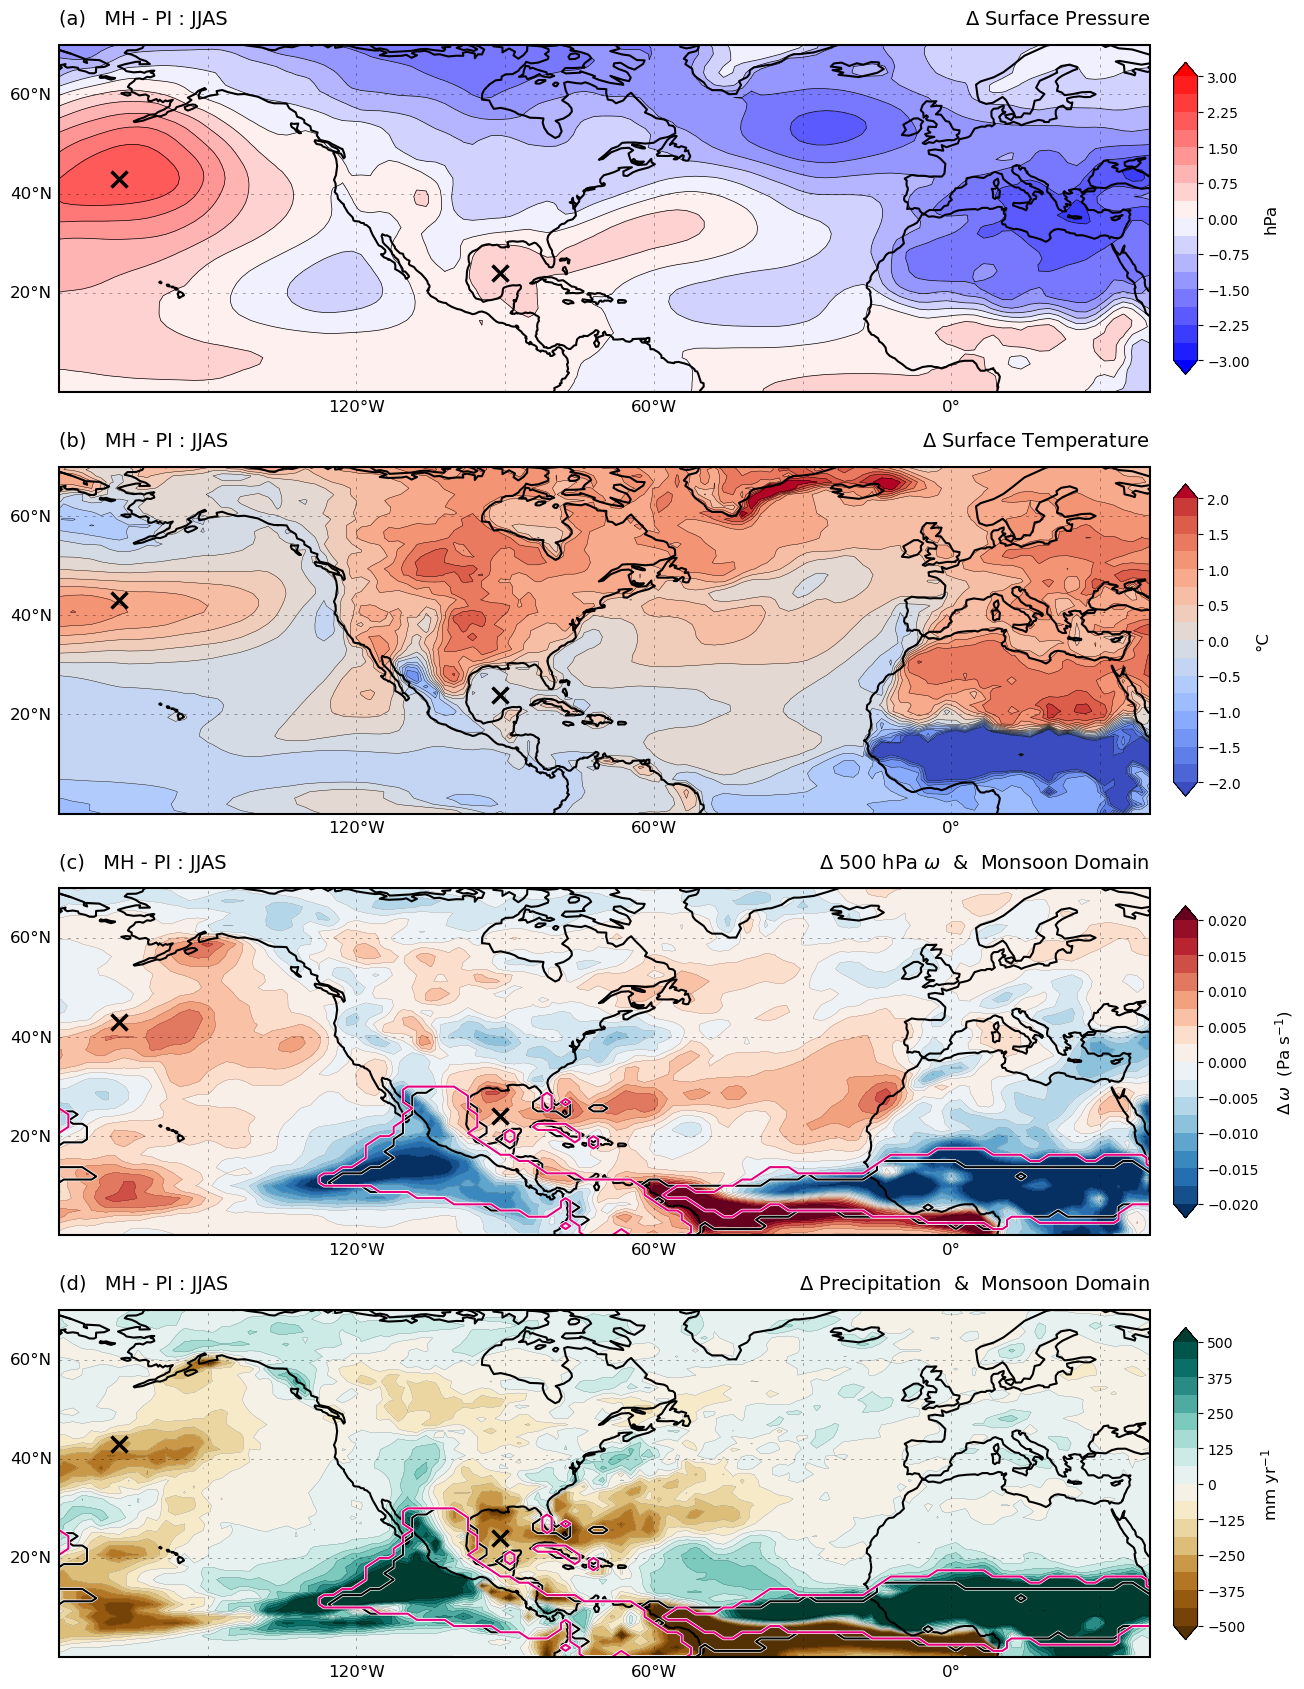

In [ ]:
#------------------------------------------------------------
# Figure Properties
#------------------------------------------------------------

fig = plt.figure(figsize=(12, 17))
gs = GridSpec(4, 1)
lims, proj = [-180, 40, 0, 70], ccrs.PlateCarree()

high_centres = {"E Pacific": (-168, 43), "GoM": (-91, 24)}

#------------------------------------------------------------
# Panel (a) - Surface Pressure Anomaly
#------------------------------------------------------------

ax_p = plt.subplot(gs[0], projection=proj)
umplt.plotBaseMap(ax_p, lims, coastlw=1.5, borders=False, spinelw=1.5)
umplt.plotGrid(ax_p, xlabeledlines=[-120, -60, 0, 60, 120], ylabeledlines=[-20, 0, 20, 40, 60], xlines=[-150, -90, -30, 30],
               labelsize=12, lw=0.4, alph=0.6)

cmap = cm.bwr; v = 3; levels = np.linspace(-v, v, 17) 
norm = BoundaryNorm(levels, cmap.N, extend="both")

p0_c, lon_p0 = add_cyclic_point(p0_anom.values, coord=p0_anom.longitude)
cf_p = ax_p.contourf(lon_p0, p0_anom.latitude, p0_c, cmap=cmap, norm=norm, extend="both", levels=levels, transform=ccrs.PlateCarree(), zorder=0)
ax_p.contour(lon_p0, p0_anom.latitude, p0_c, colors="k", levels=levels, linewidths=0.5, linestyles="solid", transform=ccrs.PlateCarree(), zorder=0)

for name, (x, y) in high_centres.items():
    ax_p.plot(x, y, "kx", ms=12, mew=2.5, transform=ccrs.PlateCarree(), zorder=3)

ax_p.set_title("(a)   MH - PI : JJAS", loc="left", pad=15, fontsize=14)
ax_p.set_title(r"$\Delta$ Surface Pressure", loc="right", pad=15, fontsize=14)

#------------------------------------------------------------
# Panel (b) - Surface Temperature Anomaly
#------------------------------------------------------------

ax_t = plt.subplot(gs[1], projection=proj)
umplt.plotBaseMap(ax_t, lims, coastlw=1.5, borders=False, spinelw=1.5)
umplt.plotGrid(ax_t, xlabeledlines=[-120, -60, 0, 60, 120], ylabeledlines=[-20, 0, 20, 40, 60], xlines=[-150, -90, -30, 30],
               labelsize=12, lw=0.4, alph=0.6)

cmap = cm.coolwarm; v = 2; levels = np.linspace(-v, v, 17) 
norm = BoundaryNorm(levels, cmap.N, extend="both")

ts_c, lon_ts = add_cyclic_point(ts_anom.values, coord=ts_anom.longitude)
cf_t = ax_t.contourf(lon_ts, ts_anom.latitude, ts_c, cmap=cmap, norm=norm, extend="both", levels=levels, transform=ccrs.PlateCarree(), zorder=0)
ax_t.contour(lon_ts, ts_anom.latitude, ts_c, colors="k", levels=levels, linewidths=0.3, linestyles="solid", transform=ccrs.PlateCarree(), zorder=0)

for name, (x, y) in high_centres.items():
    ax_t.plot(x, y, "kx", ms=12, mew=2.5, transform=ccrs.PlateCarree(), zorder=3)

ax_t.set_title("(b)   MH - PI : JJAS", loc="left", pad=15, fontsize=14)
ax_t.set_title(r"$\Delta$ Surface Temperature", loc="right", pad=15, fontsize=14)

#------------------------------------------------------------
# Panel (c) - Mid-Level Omega
#------------------------------------------------------------

ax_om = plt.subplot(gs[2], projection=proj)
umplt.plotBaseMap(ax_om, lims, coastlw=1.5, borders=False, spinelw=1.5)
umplt.plotGrid(ax_om, xlabeledlines=[-120, -60, 0, 60, 120], ylabeledlines=[-20, 0, 20, 40, 60], xlines=[-150, -90, -30, 30],
               labelsize=12, lw=0.4, alph=0.6)

cmap = cm.RdBu_r; v = 0.02; levels = np.linspace(-v, v, 17)
norm = BoundaryNorm(levels, cmap.N, extend="both")

om_c, om_lon = add_cyclic_point(om_anom.values, coord=om_anom.lon_p)
cf_om = ax_om.contourf(om_lon, om_anom.lat_p, om_c, cmap=cmap, norm=norm, extend="both",
                 levels=levels, transform=ccrs.PlateCarree(), zorder=0)
ax_om.contour(om_lon, om_anom.lat_p, om_c, colors="k", levels=levels, linewidths=0.1, linestyles="solid", transform=ccrs.PlateCarree(), zorder=0)

dom_Pc, dom_lon = add_cyclic_point(dom_P.values.astype(float), coord=dom_P.longitude)
cs_P = ax_om.contour(dom_lon, dom_P.latitude, dom_Pc, levels=[0.5], colors="k", linewidths=1.5, transform=ccrs.PlateCarree(), zorder=2)
cs_P.set_path_effects([pe.withStroke(linewidth=2.5, foreground="white")])

dom_Mc, dom_lon = add_cyclic_point(dom_M.values.astype(float), coord=dom_M.longitude)
cs_M = ax_om.contour(dom_lon, dom_M.latitude, dom_Mc, levels=[0.5], colors="#E5007D", linewidths=1.5, transform=ccrs.PlateCarree(), zorder=2)
cs_M.set_path_effects([pe.withStroke(linewidth=2.5, foreground="white")])

for name, (x, y) in high_centres.items():
    ax_om.plot(x, y, "kx", ms=12, mew=2.5, transform=ccrs.PlateCarree(), zorder=3)

ax_om.set_title("(c)   MH - PI : JJAS", loc="left", pad=15, fontsize=14)
ax_om.set_title(r"$\Delta$ 500 hPa $\omega$  &  Monsoon Domain", loc="right", pad=15, fontsize=14)


#------------------------------------------------------------
# Panel (d) - Precipitation + Upper Level Velocity Potential Contours
#------------------------------------------------------------

cmap = cm.BrBG; v_pr = 500; levels = np.linspace(-v_pr, v_pr, 17) 
norm = BoundaryNorm(levels, cmap.N, extend="both")

ax_pr = plt.subplot(gs[3], projection=proj)
umplt.plotBaseMap(ax_pr, lims, coastlw=1.5, borders=False, spinelw=1.5)
umplt.plotGrid(ax_pr, xlabeledlines=[-120, -60, 0, 60, 120], ylabeledlines=[-20, 0, 20, 40, 60], xlines=[-150, -90, -30, 30],
               labelsize=12, lw=0.4, alph=0.6)

pr_c, lon_pr = add_cyclic_point(pr_anom.values, coord=pr_anom.longitude)
cf_pr = ax_pr.contourf(lon_pr, pr_anom.latitude, pr_c, levels=levels, extend="both", cmap=cmap, norm=norm, transform=ccrs.PlateCarree(), zorder=0)
ax_pr.contour(lon_pr, pr_anom.latitude, pr_c, colors="k", levels=levels, linewidths=0.1, linestyles="solid", transform=ccrs.PlateCarree(), zorder=0)

dom_Pc, dom_lon = add_cyclic_point(dom_P.values.astype(float), coord=dom_P.longitude)
cs_P = ax_pr.contour(dom_lon, dom_P.latitude, dom_Pc, levels=[0.5], colors="k", linewidths=1.5, transform=ccrs.PlateCarree(), zorder=2)
cs_P.set_path_effects([pe.withStroke(linewidth=2.5, foreground="white")])

dom_Mc, dom_lon = add_cyclic_point(dom_M.values.astype(float), coord=dom_M.longitude)
cs_M = ax_pr.contour(dom_lon, dom_M.latitude, dom_Mc, levels=[0.5], colors="#E5007D", linewidths=1.5, transform=ccrs.PlateCarree(), zorder=2)
cs_M.set_path_effects([pe.withStroke(linewidth=2.5, foreground="white")])

for name, (x, y) in high_centres.items():
    ax_pr.plot(x, y, "kx", ms=12, mew=2.5, transform=ccrs.PlateCarree(), zorder=3)

ax_pr.set_title("(d)   MH - PI : JJAS", loc="left", pad=15, fontsize=14)
ax_pr.set_title(r"$\Delta$ Precipitation  &  Monsoon Domain", loc="right", pad=15, fontsize=14)

plt.tight_layout()
fig.canvas.draw()

panels = [
    (ax_p, cf_p, "hPa"),
    (ax_t, cf_t, "°C"),
    (ax_om, cf_om, r"$\Delta\,\omega$  (Pa s$^{-1}$)"),
    (ax_pr, cf_pr, r"mm $\mathregular{yr^{-1}}$")
]

for ax, mappable, label in panels:
    pos = ax.get_position()
    cax = fig.add_axes((pos.x1 + 0.02, pos.y0 + pos.height * 0.05, 0.02, pos.height * 0.9))
    cb = fig.colorbar(mappable, cax=cax, orientation="vertical")
    cb.set_label(label, fontsize=12, labelpad=10)
    cb.ax.minorticks_off()

plt.show()